# Threshold Sweep Analysis

This notebook performs threshold sweep analysis on pre-computed best_matches files.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, List
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

## Configuration

## Load Data

## Metric Calculation Functions

### Event Match Rate

In [5]:
from pathlib import Path

# # Choose annotation version here
# manual_version = "v3"   # options: "v3", "v2"

# # Map version to file date
# version_to_date = {
#     "v3": "2026-04-07",
#     "v2": "2026-04-09",
#     "v1": "2026-04-11"
# }

# if manual_version not in version_to_date:
#     raise ValueError(f"Unsupported manual_version: {manual_version}. Choose from {list(version_to_date)}")

# match_date = version_to_date[manual_version]

# base_dir = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/ablations/singlestep/")

# # Model name in pilot_files -> folder name on disk
# model_dirs = {
#     #"dsr1_update_only_final": "dsr1_update_only_final",
#     # "DSV31": "DeepSeek_V3.1",
#     #"DSV32_update_only_final": "DSV32_update_only_final",
#     #"glm5": "glm5_singlestep",
#     "gptoss120b_singlestep": "gptoss120b_singlestep",
#     # "gptoss120b_reasoning": "gptoss120b_reasoning",
#     #"kimik2_update_only_final": "kimik2_update_only_final",
#     "mistral4small_singlestep": "mistral4small_singlestep",
#     #"qwen35_update_only_final": "qwen35_update_only_final",
#     # "minimax25": "minimax25",
# }

# # Suffix in pilot_files -> folder name on disk
# modality_dirs = {
#     "mm": "clean_bsv_multimodal",
#     "um": "clean_bsv_unimodal",
# }

# pilot_files = {}

# for model_key, model_dir in model_dirs.items():
#     for modality_key, modality_dir in modality_dirs.items():
#         pilot_name = f"{model_key}_{modality_key}"
#         pilot_files[pilot_name] = (
#             base_dir
#             / model_dir
#             / modality_dir
#             / "matches"
#             / f"best_matches{match_date}.csv"
#         )

# # Example
# # for k, v in pilot_files.items():
# #     print(k, "->", v)

###############################
###############################

pilot_files = {}

pilot_files['glm5_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/glm5/clean_bsv_multimodal/matches/best_matches2026-04-07.csv")
pilot_files['glm5_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/glm5/clean_bsv_unimodal/matches/best_matches2026-04-07.csv")

pilot_files['dsv32_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.2/clean_bsv_multimodal/matches/best_matches2026-04-07.csv")
pilot_files['dsv32_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.2/clean_bsv_unimodal/matches/best_matches2026-04-07.csv")



print("Loading files:")
for pilot, path in pilot_files.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {exists} {pilot}: {path}")
    
def load_all_pilots(pilot_files: Dict[str, Path]) -> pd.DataFrame:
    """Load all best_matches files and combine them."""
    dfs = {}
    for pilot_name, filepath in pilot_files.items():
        df = pd.read_csv(filepath)

        case_to_exclude = ['2023-03-07_12-53-02_annotations_145785_yes_structured',
                           '2023-03-28_09-36-53_annotations_152818_yes_structured',
                           '2023-03-30_10-05-43_annotations_178300_yes_structured',
                           '2024-01-09_10-31-06_annotations_101433']
        
        df = df.loc[~df['common.bns'].isin(case_to_exclude)].reset_index(drop = True)
        
        df['pilot_name'] = pilot_name
        dfs[pilot_name] = df
    return dfs

# Load data
dfs = load_all_pilots(pilot_files)

Loading files:
  ✓ glm5_ms_mm: /Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/glm5/clean_bsv_multimodal/matches/best_matches2026-04-07.csv
  ✓ glm5_ms_um: /Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/glm5/clean_bsv_unimodal/matches/best_matches2026-04-07.csv
  ✓ dsv32_ms_mm: /Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.2/clean_bsv_multimodal/matches/best_matches2026-04-07.csv
  ✓ dsv32_ms_um: /Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.2/clean_bsv_unimodal/matches/best_matches2026-04-07.csv


In [15]:
dfs['dsv32_ms_um']['common.bns'].nunique()

16

In [17]:
def calculate_match_rate(df: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """
    Calculate event match rate.
    Match rate = percentage of events where error.rate < threshold
    """
    df_clean = df.copy()
    #df_clean = df_clean.loc[df['common.bns'] != '2023-12-11_13-58-59_annotations_jcw_100831'].reset_index(drop = True)
    
    df_clean['error.rate'] = df_clean['error.rate'].fillna(np.inf)
    
    # Use groupby and agg to calculate match rate without triggering deprecation warning
    results = df_clean.groupby('pilot_name').agg(
        match_rate=('error.rate', lambda x: (x < threshold).mean())
    ).reset_index()
    
    return results


print("\nMatch Rates at Threshold 0.1:")

for pilot_, df in dfs.items():
    result = calculate_match_rate(df, threshold=0.1)
    print(f"Pilot: {pilot_}, Match Rate: {result['match_rate'].iloc[0]:.3f}")




Match Rates at Threshold 0.1:
Pilot: glm5_ms_mm, Match Rate: 0.322
Pilot: glm5_ms_um, Match Rate: 0.322
Pilot: dsv32_ms_mm, Match Rate: 0.574
Pilot: dsv32_ms_um, Match Rate: 0.574


## calculate event rate by file

In [21]:
# pilot_files = {}

# pilot_files['DSR1_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_R1/clean_bsv_multimodal/clean2/matches/best_matches2026-03-24.csv")
# pilot_files['DSR1_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_R1/clean_bsv_unimodal/clean2/matches/best_matches2026-03-24.csv")

# pilot_files['DSV3_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.1/clean_bsv_multimodal/matches/best_matches2026-03-25.csv")
# pilot_files['DSV3_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.1/clean_bsv_unimodal/matches/best_matches2026-03-25.csv")

# pilot_files['gptoss120b_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/gptoss120b/clean_bsv_multimodal/clean2/matches/best_matches2026-03-24.csv")
# pilot_files['gptoss120b_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/gptoss120b/clean_bsv_unimodal/clean2/matches/best_matches2026-03-24.csv")


# pilot_files['qwen35_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/qwen35/clean_bsv_multimodal/clean2/matches/best_matches2026-03-25.csv")
# pilot_files['qwen35_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/qwen35/clean_bsv_unimodal/clean2/matches/best_matches2026-03-25.csv")

# pilot_files['mistral4small_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/mistral4small/clean_bsv_multimodal/clean2/matches/best_matches2026-03-25.csv")
# pilot_files['mistral4small_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/mistral4small/clean_bsv_unimodal/clean2/matches/best_matches2026-03-25.csv")

# pilot_files['glm5_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/glm5/clean_bsv_multimodal/clean2/matches/best_matches2026-03-25.csv")
# pilot_files['glm5_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/glm5/clean_bsv_unimodal/clean2/matches/best_matches2026-03-25.csv")

# pilot_files['minimax25_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/minimax25/clean_bsv_multimodal/clean2/matches/best_matches2026-03-25.csv")
# pilot_files['minimax25_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/minimax25/clean_bsv_unimodal/clean2/matches/best_matches2026-03-25.csv")

#"qwen35_ms_um", "qwen35_ms_mm", "mistral4small_ms_um", "mistral4small_ms_mm", "glm5_ms_um", "glm5_ms_mm", "minimax25_ms_um", "minimax25_ms_mm" 

# print("Loading files:")
# for pilot, path in pilot_files.items():
#     exists = "✓" if path.exists() else "✗"
#     print(f"  {exists} {pilot}: {path}")
    
# def load_all_pilots(pilot_files: Dict[str, Path]) -> pd.DataFrame:
#     """Load all best_matches files and combine them."""
#     dfs = {}
#     for pilot_name, filepath in pilot_files.items():
#         df = pd.read_csv(filepath)
#         df['pilot_name'] = pilot_name
#         dfs[pilot_name] = df
#     return dfs

# # Load data
# dfs = load_all_pilots(pilot_files)

##############################################


def calculate_EMR_perfile(df: pd.DataFrame, threshold: float) -> pd.DataFrame:

    """
    Calculate event match rate.
    Match rate = percentage of events where error.rate < threshold
    """
    df_clean = df.copy()
    df_clean['error.rate'] = df_clean['error.rate'].fillna(np.inf)
    
    filenames = df_clean['common.bns'].unique()
    
    threshold = 0.1
    match_rate_file = {}
    for file in filenames:
        df_file = df_clean.loc[df_clean['common.bns'] == file].reset_index(drop = True)
    
        results = df_file.groupby('pilot_name').agg(match_rate=('error.rate', lambda x: (x < threshold).mean())).reset_index()
    
        match_rate_file[file] = results['match_rate'].iloc[0]
    
    return match_rate_file


score_dicts = []
for pilot_, df in dfs.items():
    # if '_ms_um' in pilot_:
    result = calculate_EMR_perfile(df, threshold=0.1)
    score_dicts.append(result)
    #print(f"Pilot: {pilot_}, Match Rate: {result['match_rate'].iloc[0]:.2f}")


aliases = [k for k in list(pilot_files.keys())]
#score_dicts = [qwen_dict, llama_dict]

df = pd.DataFrame(dict(zip(aliases, score_dicts)))
df.index.name = "filename"
df = df.reset_index(drop = False)
df["filename"] = (df["filename"].str.replace(r"^\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_annotations_", "", regex=True))

#df = df.rename(columns=lambda x: x.removesuffix('_um'))

#df.to_excel("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/match_rate_per_file_manualv1.xlsx", header = True, index = False)
df



,filename,dsr1_ss_mm,dsr1_ss_um,dsr1_uoc_mm,dsr1_uof_mm,dsr1_uof_um,dsr1_ms_mm,dsr1_ms_um
0,158331_yes_structured,0.883721,0.906977,0.906977,0.909091,0.909091,0.837209,0.837209
1,133706_yes_structured,0.235294,0.235294,0.517647,0.216374,0.216374,0.341176,0.341176
2,160019_yes_structured,0.328125,0.328125,0.437500,0.400000,0.400000,0.406250,0.406250
3,145785_yes_structured,0.161017,0.161017,0.372881,0.218487,0.218487,0.279661,0.279661
4,125310_yes_structured,0.500000,0.509259,0.490741,0.522936,0.522936,0.509259,0.509259
5,164788_yes_structured,0.495495,0.495495,0.756757,0.508929,0.508929,0.675676,0.675676
6,163261_yes_structured,0.608696,0.630435,0.673913,0.638298,0.638298,0.630435,0.630435
7,152818_yes_structured,0.387097,0.387097,0.666667,0.648936,0.648936,0.666667,0.666667
8,178300_yes_structured,0.500000,0.500000,0.642857,0.366197,0.366197,0.371429,0.371429
9,162755_yes_structured,0.445946,0.445946,0.797297,0.600000,0.613333,0.783784,0.783784


### Concordance

In [21]:
"""
Concordance calculation that reads times from original CSV files.

This matches R's threshold sweep behavior where it re-reads the original
manual/pilot CSV files instead of using the times in best_matches CSV.
"""

import pandas as pd
import numpy as np


def my_cindex_r(pred, truth, ties_value=0.5, nonzero_threshold=1e-5):
    """Calculate concordance index (C-index) for temporal ordering."""
    pred = np.asarray(pred, dtype=float)
    truth = np.asarray(truth, dtype=float)
    if pred.size < 2:
        return np.nan
    truth_diff = truth[:, None] - truth[None, :]
    pred_diff  = pred[:, None]  - pred[None, :]
    mask = np.abs(truth_diff) > nonzero_threshold
    if not np.any(mask):
        return np.nan
    prod = (truth_diff * pred_diff)[mask]
    result = np.where(prod > 0, 1.0,
                      np.where(prod > -nonzero_threshold, float(ties_value), 0.0))
    return float(np.mean(result))


def load_times_from_files(df, man_has_header=True, pilot_has_header=True):
    """
    Read times from original CSV files using idx and match.idx.
    
    Args:
        df: best_matches DataFrame with columns:
            - files: path to manual CSV
            - pilot.files: path to pilot CSV  
            - idx: 1-indexed row in manual file
            - match.idx: 1-indexed row in pilot file
        man_has_header: Whether manual CSVs have header row
        pilot_has_header: Whether pilot CSVs have header row
        
    Returns:
        DataFrame with added ref.time_from_file and pilot.time_from_file columns
    """
    result = df.copy()
    
    # Cache files to avoid re-reading
    manual_cache = {}
    pilot_cache = {}
    
    ref_times = []
    pilot_times = []
    
    for i, row in result.iterrows():
        # Read manual time
        manual_file = row['files']
        
        # Handle NaN in idx
        if pd.isna(row['idx']):
            ref_time = np.nan
        else:
            manual_idx = int(row['idx'])
            
            if manual_file not in manual_cache:
                try:
                    manual_cache[manual_file] = pd.read_csv(
                        manual_file, 
                        header=0 if man_has_header else None, 
                        dtype=str
                    )
                except:
                    manual_cache[manual_file] = None
            
            manual_df = manual_cache[manual_file]
            if manual_df is not None and 0 < manual_idx <= len(manual_df):
                ref_time = manual_df.iloc[manual_idx - 1, 1]  # Column 2, 1-indexed to 0-indexed
                # R does: str_replace_all(time, "\\\\","") to remove backslashes
                if isinstance(ref_time, str):
                    ref_time = ref_time.replace('\\', '')
            else:
                ref_time = np.nan
        
        # Read pilot time
        pilot_file = row['pilot.files']
        
        # Handle NaN in match.idx
        if pd.isna(row['match.idx']):
            pilot_time = np.nan
        else:
            pilot_idx = int(row['match.idx'])
            
            if pilot_file not in pilot_cache:
                try:
                    pilot_cache[pilot_file] = pd.read_csv(
                        pilot_file,
                        header=0 if pilot_has_header else None,
                        dtype=str
                    )
                except:
                    pilot_cache[pilot_file] = None
            
            pilot_df = pilot_cache[pilot_file]
            if pilot_df is not None and 0 < pilot_idx <= len(pilot_df):
                pilot_time = pilot_df.iloc[pilot_idx - 1, 1]  # Column 2, 1-indexed to 0-indexed
                # R does: str_replace_all(time, "\\\\","") to remove backslashes
                if isinstance(pilot_time, str):
                    pilot_time = pilot_time.replace('\\', '')
            else:
                pilot_time = np.nan
        
        ref_times.append(ref_time)
        pilot_times.append(pilot_time)
    
    result['ref.time_from_file'] = ref_times
    result['pilot.time_from_file'] = pilot_times
    
    return result


def calculate_concordance(df, threshold=0.1, use_original_files=True,
                          man_has_header=True, pilot_has_header=True):
    """
    Calculate concordance metrics.
    
    Args:
        df: best_matches DataFrame
        threshold: Distance threshold for filtering
        use_original_files: If True, read times from original CSVs.
                           If False, use ref.time/pilot.time from best_matches.
        man_has_header: Whether manual CSVs have headers
        pilot_has_header: Whether pilot CSVs have headers
        
    Returns:
        Dict with Concordance (median), C25, C75
    """
    out = df.copy()
    
    # Load times from files if requested
    if use_original_files:
        out = load_times_from_files(out, man_has_header, pilot_has_header)
        time_col_ref = 'ref.time_from_file'
        time_col_pilot = 'pilot.time_from_file'
    else:
        time_col_ref = 'ref.time'
        time_col_pilot = 'pilot.time'
    
    # Apply R's filtering logic
    out = out[out['v2'].notna()].copy()
    
    out['ref.time'] = pd.to_numeric(out[time_col_ref], errors='coerce')
    out['pilot.time'] = pd.to_numeric(out[time_col_pilot], errors='coerce')
    
    out = out[out['pilot.time'].notna()].copy()
    
    out['error.rate'] = pd.to_numeric(out['error.rate'], errors='coerce')
    out = out[(out['error.rate'].notna()) & 
              (out['error.rate'] < threshold) & 
              (np.isfinite(out['error.rate']))].copy()
    
    # NOTE: R does NOT filter out NA ref.time here!
    # Those NA values will be handled by my_cindex_r (pairs with NA are excluded)
    
    if len(out) == 0:
        return {'Concordance': np.nan, 'C25': np.nan, 'C75': np.nan}
    
    # Calculate per-case concordance
    per_case = (
        out.groupby('common.bns', sort=False)
           .apply(lambda x: my_cindex_r(x['pilot.time'].values, x['ref.time'].values),
                  include_groups=False)
           .reset_index(name='concordance')
    )
    
    per_case = per_case[per_case['concordance'].notna()].copy()
    
    if len(per_case) == 0:
        return {'Concordance': np.nan, 'C25': np.nan, 'C75': np.nan}
    
    concordances = per_case['concordance'].values
    
    return {
        'Concordance': float(np.median(concordances)),
        'C75': float(np.quantile(concordances, 0.75)),
        'C25': float(np.quantile(concordances, 0.25))
    }

In [29]:
for pilot_, df in dfs.items(): # iterate over model

    #df = df.loc[df['common.bns'] != '2023-12-11_13-58-59_annotations_jcw_100831'].reset_index(drop = True)
    
    result = calculate_concordance(
        df, 
        threshold=0.1,
        use_original_files=False,
        man_has_header=True,   # Adjust based on your CSV format
        pilot_has_header=True
    )

    # print(f"Pilot: {pilot_}")
    # print(f"Concordance: {result['Concordance']:.9f}")
    
    print(f"Pilot: {pilot_}, Concordance: {result['Concordance']:.3f}, C25:  {result['C25']:.3f}, C75:  {result['C75']:.3f}")
    # print(f"C25: {result['C25']:.3f}")
    # print(f"C75: {result['C75']:.3f}")
    #print()

Pilot: glm5_ms_mm, Concordance: 0.788, C25:  0.758, C75:  0.866
Pilot: glm5_ms_um, Concordance: 0.778, C25:  0.731, C75:  0.881
Pilot: dsv32_ms_mm, Concordance: 0.759, C25:  0.702, C75:  0.823
Pilot: dsv32_ms_um, Concordance: 0.744, C25:  0.717, C75:  0.824


### Calculate concordance per file

In [27]:
###################################


print("\nConcordance at Threshold 0.1:")

score_dicts = []

for pilot_, df in dfs.items(): # iterate over model

    df = df.loc[df['common.bns'] != '2023-12-11_13-58-59_annotations_jcw_100831'].reset_index(drop = True)

    filenames = df['common.bns'].unique()
    
    cidx_per_file = {}
    for file in filenames: # iterate over filenames
        df_file = df.loc[df['common.bns'] == file].reset_index(drop = True)
    
        result = calculate_concordance(
            df_file, 
            threshold=0.1,
            use_original_files=False,
            man_has_header=True,   # Adjust based on your CSV format
            pilot_has_header=True
        )

        cidx_per_file[file] = result['Concordance']

    score_dicts.append(cidx_per_file)

    # print(f"Pilot: {pilot_}")
    # print(f"Concordance: {result['Concordance']:.9f}")
    # print(f"C25: {result['C25']:.9f}")
    # print(f"C75: {result['C75']:.9f}")
    # print()

aliases= [k for k in list(pilot_files.keys())]

df = pd.DataFrame(dict(zip(aliases, score_dicts)))
df.index.name = "filename"
df = df.reset_index(drop = False)
df["filename"] = (df["filename"].str.replace(r"^\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_annotations_", "", regex=True))

#df.round(3).to_excel("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/concordance_per_file_manualv1.xlsx", header = True, index = False)
df




Concordance at Threshold 0.1:


,filename,dsr1_ss_mm,dsr1_ss_um,dsr1_uoc_mm,dsr1_uof_mm,dsr1_uof_um,dsr1_ms_mm,dsr1_ms_um
0,158331_yes_structured,0.829142,0.833801,0.838235,0.888220,0.881526,0.793388,0.793388
1,133706_yes_structured,0.481530,0.553430,0.614189,0.751577,0.751577,0.626952,0.643245
2,160019_yes_structured,0.793194,0.793194,0.813272,0.780702,0.782456,0.874539,0.870849
3,145785_yes_structured,0.844118,0.829412,0.767271,0.822222,0.822222,0.829077,0.814342
4,125310_yes_structured,0.603336,0.617318,0.745262,0.797572,0.799869,0.735211,0.739437
5,164788_yes_structured,0.702703,0.871246,0.839342,0.755577,0.761483,0.850000,0.850000
6,163261_yes_structured,0.607143,0.664456,0.723235,0.722087,0.743932,0.733681,0.733681
7,152818_yes_structured,0.807958,0.724913,0.757687,0.750825,0.760066,0.666771,0.667710
8,178300_yes_structured,0.952618,0.900249,0.808667,0.791667,0.761667,0.791667,0.795000
9,162755_yes_structured,0.759557,0.751509,0.759115,0.727848,0.643873,0.732070,0.710758


## Statistical analyses - multimodal vs unimodal 

In [17]:
import re
import itertools
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, friedmanchisquare
from statsmodels.stats.multitest import multipletests


# -----------------------------
# Helpers
# -----------------------------
def parse_model_columns(df, id_col="filename"):
    """
    Returns:
        models: sorted list of model names
        modality_map: dict like {"DSR1": {"mm": "DSR1_mm", "um": "DSR1_um"}, ...}
    """
    modality_map = {}
    pattern = re.compile(r"^(.*)_(mm|um)$")

    for col in df.columns:
        if col == id_col:
            continue
        m = pattern.match(col)
        if m:
            model, modality = m.group(1), m.group(2)
            modality_map.setdefault(model, {})[modality] = col

    models = sorted(modality_map.keys())
    return models, modality_map


def rank_biserial_from_paired_diff(diff):
    """
    Rank-biserial correlation for paired Wilcoxon signed-rank setting.
    diff: numpy array of paired differences
    """
    diff = np.asarray(diff, dtype=float)
    diff = diff[~np.isnan(diff)]
    diff = diff[diff != 0]

    if len(diff) == 0:
        return 0.0

    abs_diff = np.abs(diff)
    ranks = pd.Series(abs_diff).rank(method="average").to_numpy()

    w_pos = ranks[diff > 0].sum()
    w_neg = ranks[diff < 0].sum()
    denom = w_pos + w_neg

    if denom == 0:
        return 0.0
    return (w_pos - w_neg) / denom


def safe_paired_wilcoxon(x, y):
    """
    Paired Wilcoxon with guardrails.
    Returns dict with n, statistic, pvalue, mean_diff, median_diff, rbc.
    """
    pair = pd.DataFrame({"x": x, "y": y}).dropna()
    n = len(pair)

    if n < 2:
        return {
            "n": n,
            "statistic": np.nan,
            "pvalue": np.nan,
            "mean_diff": np.nan,
            "median_diff": np.nan,
            "rank_biserial": np.nan,
        }

    diff = (pair["x"] - pair["y"]).to_numpy(dtype=float)

    # All equal -> no difference
    if np.allclose(diff, 0):
        return {
            "n": n,
            "statistic": 0.0,
            "pvalue": 1.0,
            "mean_diff": float(np.mean(diff)),
            "median_diff": float(np.median(diff)),
            "rank_biserial": 0.0,
        }

    try:
        res = wilcoxon(pair["x"], pair["y"], zero_method="wilcox", alternative="two-sided", method="auto")
        stat = float(res.statistic)
        pval = float(res.pvalue)
    except ValueError:
        # fallback for edge cases
        stat = np.nan
        pval = np.nan

    return {
        "n": n,
        "statistic": stat,
        "pvalue": pval,
        "mean_diff": float(np.mean(diff)),
        "median_diff": float(np.median(diff)),
        "rank_biserial": float(rank_biserial_from_paired_diff(diff)),
    }


# -----------------------------
# 1) Multimodal vs unimodal per model
# -----------------------------
def compare_mm_vs_um(df, id_col="filename", correction="holm"):
    models, modality_map = parse_model_columns(df, id_col=id_col)

    rows = []
    for model in models:
        if "mm" not in modality_map[model] or "um" not in modality_map[model]:
            continue

        mm_col = modality_map[model]["mm"]
        um_col = modality_map[model]["um"]

        out = safe_paired_wilcoxon(df[mm_col], df[um_col])
        out["model"] = model
        out["mm_col"] = mm_col
        out["um_col"] = um_col
        rows.append(out)

    results = pd.DataFrame(rows)

    if not results.empty:
        mask = results["pvalue"].notna()
        results["p_adj"] = np.nan
        results["reject"] = False

        if mask.sum() > 0:
            rej, p_adj, _, _ = multipletests(results.loc[mask, "pvalue"], method=correction)
            results.loc[mask, "p_adj"] = p_adj
            results.loc[mask, "reject"] = rej

        results = results[
            ["model", "n", "mean_diff", "median_diff", "rank_biserial",
             "statistic", "pvalue", "p_adj", "reject", "mm_col", "um_col"]
        ].sort_values("p_adj", na_position="last")

    return results


# -----------------------------
# 2) Omnibus + post-hoc model comparisons within a modality
# -----------------------------
def compare_models_within_modality(
    df,
    modality="mm",
    id_col="filename",
    correction="holm",
    pairwise_use_complete_case_subset=False,
):
    """
    modality: 'mm' or 'um'

    Omnibus:
      Friedman test on complete-case rows across all available models in this modality.

    Post-hoc:
      Pairwise Wilcoxon across all model pairs.
      By default uses pairwise-complete rows for each pair.
      If pairwise_use_complete_case_subset=True, uses the same complete-case subset as omnibus.
    """
    models, modality_map = parse_model_columns(df, id_col=id_col)

    cols = []
    model_names = []
    for model in models:
        if modality in modality_map[model]:
            cols.append(modality_map[model][modality])
            model_names.append(model)

    if len(cols) < 3:
        omnibus = {
            "modality": modality,
            "n_complete": 0,
            "friedman_statistic": np.nan,
            "friedman_pvalue": np.nan,
            "models": model_names,
            "message": "Need at least 3 models for Friedman test."
        }
        pairwise = pd.DataFrame()
        return omnibus, pairwise

    complete_df = df[[id_col] + cols].dropna()
    n_complete = len(complete_df)

    if n_complete < 2:
        omnibus = {
            "modality": modality,
            "n_complete": n_complete,
            "friedman_statistic": np.nan,
            "friedman_pvalue": np.nan,
            "models": model_names,
            "message": "Not enough complete rows for omnibus Friedman test."
        }
        pairwise = pd.DataFrame()
        return omnibus, pairwise

    friedman_res = friedmanchisquare(*[complete_df[c].to_numpy() for c in cols])
    omnibus = {
        "modality": modality,
        "n_complete": n_complete,
        "friedman_statistic": float(friedman_res.statistic),
        "friedman_pvalue": float(friedman_res.pvalue),
        "models": model_names,
        "message": None,
    }

    # Post-hoc pairwise tests
    rows = []
    for model_a, model_b in itertools.combinations(model_names, 2):
        col_a = modality_map[model_a][modality]
        col_b = modality_map[model_b][modality]

        if pairwise_use_complete_case_subset:
            pair_df = complete_df[[col_a, col_b]].dropna()
        else:
            pair_df = df[[col_a, col_b]].dropna()

        out = safe_paired_wilcoxon(pair_df[col_a], pair_df[col_b])
        out["modality"] = modality
        out["model_a"] = model_a
        out["model_b"] = model_b
        out["col_a"] = col_a
        out["col_b"] = col_b
        rows.append(out)

    pairwise = pd.DataFrame(rows)

    if not pairwise.empty:
        mask = pairwise["pvalue"].notna()
        pairwise["p_adj"] = np.nan
        pairwise["reject"] = False

        if mask.sum() > 0:
            rej, p_adj, _, _ = multipletests(pairwise.loc[mask, "pvalue"], method=correction)
            pairwise.loc[mask, "p_adj"] = p_adj
            pairwise.loc[mask, "reject"] = rej

        pairwise = pairwise[
            ["modality", "model_a", "model_b", "n",
             "mean_diff", "median_diff", "rank_biserial",
             "statistic", "pvalue", "p_adj", "reject", "col_a", "col_b"]
        ].sort_values("p_adj", na_position="last")

    return omnibus, pairwise


# -----------------------------
# 3) Long format helper (optional / useful)
# -----------------------------
def to_long_format(df, id_col="filename"):
    models, modality_map = parse_model_columns(df, id_col=id_col)
    rows = []

    for _, row in df.iterrows():
        sid = row[id_col]
        for model in models:
            for modality in ["mm", "um"]:
                col = modality_map.get(model, {}).get(modality)
                if col is None:
                    continue
                rows.append({
                    id_col: sid,
                    "model": model,
                    "modality": modality,
                    "score": row[col]
                })

    return pd.DataFrame(rows)


# -----------------------------
# 4) Full analysis wrapper
# -----------------------------
def run_all_concordance_tests(df, id_col="filename", correction="holm"):
    mm_vs_um = compare_mm_vs_um(df, id_col=id_col, correction=correction)

    omnibus_mm, posthoc_mm = compare_models_within_modality(
        df, modality="mm", id_col=id_col, correction=correction
    )
    omnibus_um, posthoc_um = compare_models_within_modality(
        df, modality="um", id_col=id_col, correction=correction
    )

    return {
        "mm_vs_um_per_model": mm_vs_um,
        "omnibus_mm": omnibus_mm,
        "posthoc_mm": posthoc_mm,
        "omnibus_um": omnibus_um,
        "posthoc_um": posthoc_um,
        "long_df": to_long_format(df, id_col=id_col),
    }

In [18]:
results_concordance = run_all_concordance_tests(df, id_col="filename", correction="holm")

# print("\n=== Multimodal vs Unimodal (within each model) ===")
# print(results_concordance["mm_vs_um_per_model"])

# print("\n=== Omnibus across models: multimodal ===")
# print(results_concordance["omnibus_mm"])

# print("\n=== Post-hoc pairwise model comparisons: multimodal ===")
# print(results_concordance["posthoc_mm"])

# print("\n=== Omnibus across models: unimodal ===")
# print(results_concordance["omnibus_um"])

# print("\n=== Post-hoc pairwise model comparisons: unimodal ===")
# print(results_concordance["posthoc_um"])

results_concordance['mm_vs_um_per_model']

,model,n,mean_diff,median_diff,rank_biserial,statistic,pvalue,p_adj,reject,mm_col,um_col
6,qwen35_397B_ms,19,-0.008620,-0.000423,-0.470588,36.0,0.097989,0.685925,False,qwen35_397B_ms_mm,qwen35_397B_ms_um
0,DSR1_ms,19,-0.006125,0.000000,0.044118,65.0,0.876722,1.000000,False,DSR1_ms_mm,DSR1_ms_um
1,DSV32_ms,19,-0.008876,0.000914,0.044118,65.0,0.876722,1.000000,False,DSV32_ms_mm,DSV32_ms_um
2,glm5_ms,19,0.005360,0.000000,0.230769,35.0,0.463071,1.000000,False,glm5_ms_mm,glm5_ms_um
3,gptoss120b_ms,19,-0.010011,0.000000,-0.163399,64.0,0.554034,1.000000,False,gptoss120b_ms_mm,gptoss120b_ms_um
4,kimik2_instruct_ms,19,0.001146,0.000000,-0.032967,44.0,0.916512,1.000000,False,kimik2_instruct_ms_mm,kimik2_instruct_ms_um
5,mistral4small_ms,19,0.011218,0.001292,0.161765,57.0,0.569494,1.000000,False,mistral4small_ms_mm,mistral4small_ms_um


### AULTC

In [31]:
"""
AULTC (Area Under Log Time Curve) calculation matching R implementation.

This calculates the area under the empirical CDF curve of log-transformed
time discrepancies between matched annotations.
"""

import pandas as pd
import numpy as np


def ecdf_auc2(field_values, upper_limit):
    """
    Calculate AUC of empirical CDF.
    
    Matches R's ecdf_auc2 function which:
    1. Adds upper bound to data
    2. Sorts values
    3. Caps at upper limit
    4. Computes empirical CDF areas as rectangles
    5. Normalizes by upper limit
    
    Args:
        field_values: Array of log-transformed time differences
        upper_limit: Upper bound for the curve (log scale)
        
    Returns:
        Normalized AUC value
    """
    # Combine data with upper bound
    df = pd.DataFrame({'field': list(field_values) + [upper_limit]})
    
    # Sort by field
    df = df.sort_values('field').reset_index(drop=True)
    
    # Cap values at upper
    df['field'] = df['field'].clip(upper=upper_limit)
    
    # Calculate next value (lead)
    df['field2'] = df['field'].shift(-1, fill_value=0)
    
    # Calculate empirical CDF positions
    # R: nth = (1:n())/(n()-1)
    n = len(df)
    df['nth'] = np.arange(1, n + 1) / (n - 1)
    
    # Calculate step size and box area
    df['dx'] = df['field2'] - df['field']
    df['box'] = df['dx'] * df['nth']
    
    # Remove last row (after computing boxes)
    df = df.iloc[:-1]
    
    # Sum boxes and normalize by upper limit
    auc = df['box'].sum() / upper_limit
    
    return float(auc)


def calculate_aultc(df, threshold=0.1, upper_limit=None, 
                    use_original_files=True,
                    man_has_header=True, pilot_has_header=True,
                    version_column=None):
    """
    Calculate AULTC (Area Under Log Time Curve) for time discrepancy.
    
    This matches R's calculate_time_discrepancy function.
    
    Args:
        df: best_matches DataFrame with columns:
            - error.rate: matching error rate
            - time/time.pilot OR ref.time/pilot.time: time values
            - optionally a version/grouping column
        threshold: Distance threshold for filtering matches
        upper_limit: Upper bound for log time (default: log(60*24*365.26) ≈ 1 year)
        use_original_files: If True, load times from original CSV files
        man_has_header: Whether manual CSVs have headers
        pilot_has_header: Whether pilot CSVs have headers  
        version_column: Column name to group by (e.g., 'pilot.names', 'Version')
                       If None, calculates overall AULTC
        
    Returns:
        If version_column is None: float (overall AULTC)
        If version_column is set: DataFrame with columns [version_column, 'auc']
    """
    if upper_limit is None:
        upper_limit = np.log(60 * 24 * 365.26)  # 1 year in log minutes
    
    out = df.copy()
    
    # Handle column naming - R uses 'time' and 'time.pilot' internally
    # but CSVs may have 'ref.time' and 'pilot.time'
    if use_original_files and 'files' in out.columns and 'pilot.files' in out.columns:
        # from concordance_calculator import load_times_from_files
        out = load_times_from_files(out, man_has_header, pilot_has_header)
        # Rename to match R's internal naming
        out = out.rename(columns={
            'ref.time_from_file': 'time',
            'pilot.time_from_file': 'time.pilot'
        })
    else:
        # Map CSV columns to R's internal naming
        if 'time' not in out.columns:
            if 'ref.time' in out.columns:
                out = out.rename(columns={'ref.time': 'time'})
            else:
                raise ValueError("Missing time column (need 'time' or 'ref.time')")
        
        if 'time.pilot' not in out.columns:
            if 'pilot.time' in out.columns:
                out = out.rename(columns={'pilot.time': 'time.pilot'})
            else:
                raise ValueError("Missing pilot time column (need 'time.pilot' or 'pilot.time')")
    
    # Apply R's filtering logic - EXACTLY matching R code line 520-524:
    # mutate(time.pilot = as.numeric(time.pilot)) %>%
    # filter(!is.na(time.pilot), !is.na(event)) %>%
    # mutate(keep=error.rate < threshold, threshold = threshold) %>%
    # filter(keep) %>%
    
    out['error.rate'] = pd.to_numeric(out['error.rate'], errors='coerce')
    out = out[(out['error.rate'].notna()) & 
              (out['error.rate'] < threshold) &
              (np.isfinite(out['error.rate']))].copy()
    
    if len(out) == 0:
        if version_column:
            return pd.DataFrame(columns=[version_column, 'auc'])
        return np.nan
    
    # Convert times to numeric - matching R exactly
    # R: as.numeric(time.pilot) and as.numeric(time)
    out['time'] = pd.to_numeric(out['time'], errors='coerce')
    out['time.pilot'] = pd.to_numeric(out['time.pilot'], errors='coerce')
    
    # R has additional filters!
    # filter(!is.na(time.pilot), !is.na(event))
    out = out[out['time.pilot'].notna()].copy()
    if 'event' in out.columns or 'v1' in out.columns:
        event_col = 'event' if 'event' in out.columns else 'v1'
        out = out[out[event_col].notna()].copy()
    
    if len(out) == 0:
        if version_column:
            return pd.DataFrame(columns=[version_column, 'auc'])
        return np.nan
    
    # Calculate absolute error
    # R: ae = abs(as.numeric(time.pilot) - as.numeric(time))
    out['ae'] = (out['time.pilot'] - out['time']).abs()
    
    # Calculate log absolute error + 1
    # R: lae = ifelse(is.na(ae), exp(upper_limit)+1, ae+1)
    out['lae'] = np.where(
        out['ae'].isna(),
        np.exp(upper_limit) + 1,
        out['ae'] + 1
    )
    
    # Group by version if specified, otherwise calculate overall
    if version_column and version_column in out.columns:
        # R: select(Version, lae) %>% nest(data=-Version)
        results = []
        for version, group in out.groupby(version_column, sort=False):
            if len(group) > 0:
                # R: field=lae %>% mutate(field=log(field)) %>% ecdf_auc2
                field_values = np.log(group['lae'].values)
                auc = ecdf_auc2(field_values, upper_limit)
                results.append({version_column: version, 'auc': auc})
        
        return pd.DataFrame(results)
    else:
        # Calculate overall AULTC
        field_values = np.log(out['lae'].values)
        return ecdf_auc2(field_values, upper_limit)




In [33]:
def calculate_aultc_agg(df, threshold=0.1, upper_limit=None):
    """
    Simplified AULTC calculation for flat best_matches DataFrame.
    
    Handles both column naming conventions:
    - R internal: 'time' and 'time.pilot'
    - CSV format: 'ref.time' and 'pilot.time'
    
    Args:
        df: DataFrame with error.rate and time columns
        threshold: Error rate threshold
        upper_limit: Upper bound for log time (default: log(1 year in minutes))
        
    Returns:
        Float AULTC value
    """
    if upper_limit is None:
        upper_limit = np.log(60 * 24 * 365.26)
    
    return calculate_aultc(
        df, 
        threshold=threshold,
        upper_limit=upper_limit,
        use_original_files=False,
        version_column=None
    )

result_all_models = {}
for pilot_, df in dfs.items():

    df = df.loc[df['common.bns'] != '2023-12-11_13-58-59_annotations_jcw_100831'].reset_index(drop = True)
    
    #print(pilot_)
    result = calculate_aultc_agg(df, threshold=0.1, upper_limit=np.log(60*24*365.26))
    print(f"{pilot_}, AULTC: {result:.3f}")

glm5_ms_mm, AULTC: 0.835
glm5_ms_um, AULTC: 0.822
dsv32_ms_mm, AULTC: 0.816
dsv32_ms_um, AULTC: 0.813


In [22]:
def calculate_aultc_perfile(df, threshold=0.1, upper_limit=None):
    """
    Simplified AULTC calculation for flat best_matches DataFrame.
    
    Handles both column naming conventions:
    - R internal: 'time' and 'time.pilot'
    - CSV format: 'ref.time' and 'pilot.time'
    
    Args:
        df: DataFrame with error.rate and time columns
        threshold: Error rate threshold
        upper_limit: Upper bound for log time (default: log(1 year in minutes))
        
    Returns:
        Float AULTC value
    """
    if upper_limit is None:
        upper_limit = np.log(60 * 24 * 365.26)
    
    return calculate_aultc(
        df, 
        threshold=threshold,
        upper_limit=upper_limit,
        use_original_files=False,
        version_column='common.bns'
    )

result_all_models = {}
for pilot_, df in dfs.items():

    df = df.loc[df['common.bns'] != '2023-12-11_13-58-59_annotations_jcw_100831'].reset_index(drop = True)
    
    #print(pilot_)
    result = calculate_aultc_perfile(df, threshold=0.1, upper_limit=np.log(60*24*365.26))
    #print(f"{pilot_}, AULTC: {result:.3f}")
    #print(result)
    result_all_models[pilot_] = result

#result_all_models

### Calculate aultc per file

In [24]:
import pandas as pd

combined = None

for model_name, df_model in result_all_models.items():
    temp = df_model[["common.bns", "auc"]].copy()
    temp = temp.rename(columns={"common.bns": "filename", "auc": model_name})
    
    if combined is None:
        combined = temp
    else:
        combined = combined.merge(temp, on="filename", how="outer")

df = combined.sort_values("filename").reset_index(drop=True)

df["filename"] = df["filename"].str.replace(
    r"^\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_annotations_", "", regex=True
)

df.round(3).to_excel("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/aultc_per_file_manualv1.xlsx", header = True, index = False)

results_aultc = run_all_concordance_tests(df, id_col="filename", correction="holm")

df.round(3)



,filename,DSR1_ms_mm,DSR1_ms_um,DSV32_ms_mm,DSV32_ms_um,glm5_ms_mm,glm5_ms_um,gptoss120b_ms_mm,gptoss120b_ms_um,kimik2_instruct_ms_mm,kimik2_instruct_ms_um,mistral4small_ms_mm,mistral4small_ms_um,qwen35_397B_ms_mm,qwen35_397B_ms_um
0,158331_yes_structured,0.759,0.759,0.799,0.798,0.752,0.752,0.773,0.767,0.701,0.704,0.712,0.729,0.752,0.756
1,133706_yes_structured,0.819,0.804,0.806,0.791,0.831,0.811,0.791,0.788,0.804,0.793,0.727,0.731,0.838,0.816
2,160019_yes_structured,0.901,0.895,0.835,0.830,0.897,0.897,0.780,0.766,0.751,0.839,0.724,0.717,0.842,0.843
3,145785_yes_structured,0.838,0.830,0.893,0.862,0.895,0.896,0.819,0.818,0.818,0.827,0.787,0.788,0.853,0.847
4,125310_yes_structured,0.807,0.810,0.822,0.798,0.835,0.829,0.791,0.791,0.804,0.781,0.809,0.823,0.823,0.826
5,164788_yes_structured,0.787,0.787,0.752,0.752,0.626,0.626,0.786,0.751,0.737,0.762,0.681,0.638,0.816,0.789
6,163261_yes_structured,0.719,0.719,0.759,0.759,0.781,0.766,0.778,0.784,0.776,0.756,0.769,0.765,0.744,0.744
7,152818_yes_structured,0.800,0.800,0.783,0.786,0.772,0.773,0.784,0.785,0.758,0.758,0.719,0.712,0.794,0.794
8,178300_yes_structured,0.820,0.805,0.917,0.889,0.935,0.933,0.893,0.901,0.848,0.722,0.778,0.784,0.855,0.827
9,162755_yes_structured,0.854,0.852,0.906,0.902,0.906,0.902,0.874,0.876,0.892,0.894,0.877,0.878,0.878,0.882


In [25]:
results_aultc['mm_vs_um_per_model']

,model,n,mean_diff,median_diff,rank_biserial,statistic,pvalue,p_adj,reject,mm_col,um_col
2,glm5_ms,19,0.008480,0.001813,0.750000,17.0,0.008361,0.058525,False,glm5_ms_mm,glm5_ms_um
0,DSR1_ms,19,0.001108,0.000000,0.205882,54.0,0.469113,1.000000,False,DSR1_ms_mm,DSR1_ms_um
1,DSV32_ms,19,0.003237,0.000093,0.220588,53.0,0.437967,1.000000,False,DSV32_ms_mm,DSV32_ms_um
3,gptoss120b_ms,19,0.001301,-0.000056,-0.017544,84.0,0.947915,1.000000,False,gptoss120b_ms_mm,gptoss120b_ms_um
4,kimik2_instruct_ms,19,0.003886,0.000000,0.252747,34.0,0.421579,1.000000,False,kimik2_instruct_ms_mm,kimik2_instruct_ms_um
5,mistral4small_ms,19,0.003020,0.000000,0.254902,57.0,0.355959,1.000000,False,mistral4small_ms_mm,mistral4small_ms_um
6,qwen35_397B_ms,19,0.004793,0.000000,0.281046,55.0,0.308788,1.000000,False,qwen35_397B_ms_mm,qwen35_397B_ms_um


## Run Threshold Sweep

In [274]:
def calculate_aultc_simple(df, threshold=0.1, upper_limit=None):
    
    if upper_limit is None:
        upper_limit = np.log(60 * 24 * 365.26)
    
    return calculate_aultc(
        df, 
        threshold=threshold,
        upper_limit=upper_limit,
        use_original_files=False,
        version_column=None
    )


results = {}
THRESHOLDS = [
    0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
    0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45, 0.5
]

THRESHOLDS = np.arange(0.01, 0.51, 0.01).round(2)

for pilot_, df in dfs.items():
    if 'minimax25' not in pilot_:
        results[pilot_] = {"thresholds": [], "event_match_rate": [], 'concordance': [], "aultc": []}
        for thresholds in THRESHOLDS:
            # Event match rate
            emr_result = calculate_match_rate(df, threshold=thresholds)
            match_rate = emr_result['match_rate'].iloc[0]
            
            # Concordance
            conc_result = calculate_concordance(
                df, 
                threshold=thresholds,
                use_original_files=False
            )
            concordance = conc_result['Concordance']
    
            # AULTC
            aultc_result = calculate_aultc_simple(
                df,
                threshold=thresholds,
                upper_limit=np.log(60*24*365.26)
            )
            aultc = aultc_result
    
            # Store results
            results[pilot_]["thresholds"].append(thresholds)
            results[pilot_]["event_match_rate"].append(match_rate)
            results[pilot_]["concordance"].append(concordance)
            results[pilot_]["aultc"].append(aultc)

In [276]:

# results_new = results.copy()

# for key in ['gptoss120b_reasoning_ms_mm', 'gptoss120b_reasoning_ms_um']:
#     results_new.pop(key, None)


results.keys()

dict_keys(['dsr1_ss_mm', 'dsr1_ss_um', 'dsr1_uoc_mm', 'dsr1_uof_mm', 'dsr1_uof_um', 'dsr1_ms_mm', 'dsr1_ms_um'])

In [278]:
import matplotlib.pyplot as plt
import numpy as np

#results = results_new.copy()
#"DSR1", "DS-L33-70b", "L33-70B", "GPT5", "O1", "O3", "O4mini"

##Model name and color mapping
model_name_mapping = {
    'dsr1_ss_mm': 'singlestep multimodal', 
    'dsr1_ss_um': 'singlestep_unimodal', 
    'dsr1_uoc_mm': 'update_only_central_multimodal', 
    'dsr1_uof_mm': 'update_only_final_multimodal',
    'dsr1_uof_um': 'update_only_final_unimodal',
    'dsr1_ms_mm': 'update_both_multimodal',
    'dsr1_ms_um': 'update_both_multimodal',
}

color_mapping = {
    'dsr1_ss_mm': '#E69F00',
    'dsr1_ss_um': '#E69F00',
    'dsr1_uoc_mm': '#009E73', 
    'dsr1_uof_mm': '#56B4E9',
    'dsr1_uof_um': '#56B4E9',
    'dsr1_ms_mm': '#CC79A7',
    'dsr1_ms_um': '#CC79A7',
    # 'gptoss120b_ms_um': '#009E73',
    # 'kimik2_instruct_ms_mm': '#D55E00',
    # 'kimik2_instruct_ms_um': '#D55E00',
    # 'mistral4small_ms_mm': '#0072B2',
    # 'mistral4small_ms_um': '#0072B2',
    # 'qwen35_397B_ms_mm': '#000000',
    # 'qwen35_397B_ms_um': '#000000',
}

COLORS = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

#000000 — black
#E69F00 — orange
#56B4E9 — sky blue
#009E73 — bluish green
#F0E442 — yellow
#0072B2 — blue
#D55E00 — vermillion / reddish orange
#CC79A7 — reddish purple / magenta

# model_name_mapping = {'A2_vs_A1':'A2_vs_A1'}
# color_mapping = {'A2_vs_A1':'#D55E00'}

PILOT_ORDER = list(results.keys())
print(PILOT_ORDER)


#["DSR1_ms_mm", "DSR1_ms_um", "DSV3_ms_mm", "DSV3_ms_um", "gptoss_ms_mm", "gptoss_ms_um", "mistral_ms_um"]

# Color palette (matching R code)
# COLORS = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
# COLOR_MAP = {pilot: COLORS[i] for i, pilot in enumerate(PILOT_ORDER)}


# pilot_files['DSR1_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_R1/clean_bsv_multimodal/matches/best_matches2026-03-19.csv")
# pilot_files['DSR1_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_R1/clean_bsv_unimodal/matches/best_matches2026-03-19.csv") 
# pilot_files['DSV3_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.1/clean_bsv_multimodal/matches/best_matches2026-03-19.csv")
# pilot_files['DSV3_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/DeepSeek_V3.1/clean_bsv_unimodal/matches/best_matches2026-03-19.csv")
# pilot_files['gptoss_ms_mm'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/gptoss120b/clean_bsv_multimodal/matches/best_matches2026-03-19.csv")
# pilot_files['gptoss_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/gptoss120b/clean_bsv_unimodal/matches/best_matches2026-03-19.csv") 
# pilot_files['mistral_ms_um'] = Path("/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/multistep/mistral3large/clean_bsv_unimodal/matches/best_matches2026-03-19.csv")



['dsr1_ss_mm', 'dsr1_ss_um', 'dsr1_uoc_mm', 'dsr1_uof_mm', 'dsr1_uof_um', 'dsr1_ms_mm', 'dsr1_ms_um']


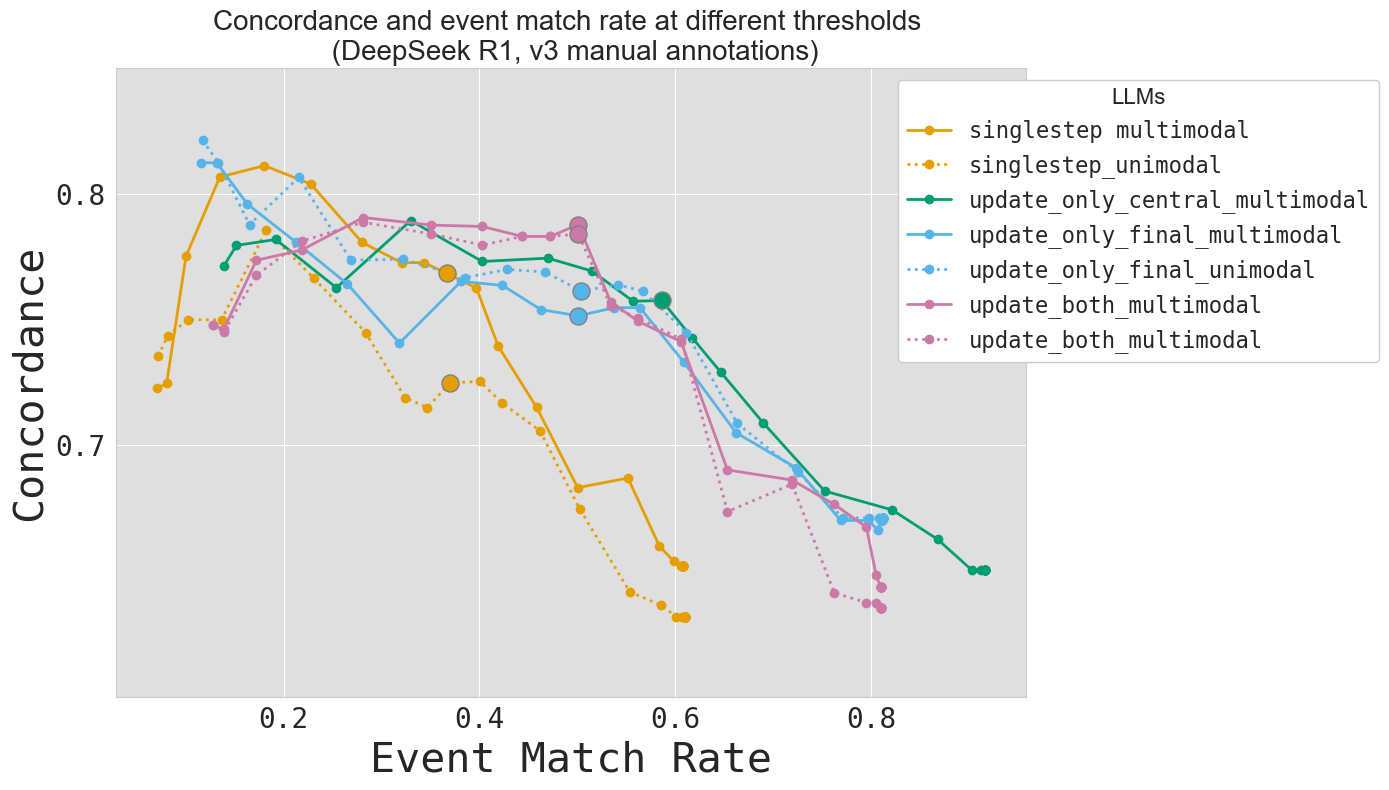

In [284]:


# Threshold to highlight with larger point
BOLD_THRESHOLD = 0.1

# Thresholds to sweep
THRESHOLDS = [
    0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
    0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45, 0.5
]

# Create Concordance vs Event Match Rate figure
plt.figure(figsize=(15, 8))

for pilot, data in results.items():
    thresholds = np.array(data['thresholds'])
    event_match_rate = np.array(data['event_match_rate'])
    concordance = np.array(data['concordance'])

    # if pilot == 'DSR1':
    #     # Skip DSR1 for AULTC plot as per original code
    #     event_match_rate = event_match_rate.copy() - 0.096481
    #     # break
    
    # Get the proper model name and color from the mapping
    model_name = model_name_mapping.get(pilot, pilot)
    color = color_mapping.get(pilot, '#000000')  # Default to black if no color found

    # Highlight threshold = 0.1
    highlight_idx = thresholds == 0.1
    highlight_x = event_match_rate[highlight_idx]
    highlight_y = concordance[highlight_idx]

    if '_um' in pilot:
        plt.plot(event_match_rate, concordance, label=model_name, marker='o', markersize=6, linestyle=':', linewidth=2, color = color)
    else:
        plt.plot(event_match_rate, concordance, label=model_name, marker='o', markersize=6, linestyle='-', linewidth=2, color = color)

    # Plot Concordance vs Event Match Rate
    #plt.plot(event_match_rate, concordance, label=model_name, marker='o', markersize=6, linestyle='-', linewidth=3, color=color)
    
    # Highlight with same color as the line, but with a black border
    plt.scatter(highlight_x, highlight_y, color = color, s=150, zorder=5, edgecolor='gray', linewidth=1) 

# Set y-axis ticks to 0.7, 0.8, 0.9, 1.0
plt.yticks(np.arange(0.7, 1.1, 0.1), fontsize=20, family='monospace')

plt.xlabel('Event Match Rate', fontsize=30, family='monospace')
plt.ylabel('Concordance', fontsize=30, family='monospace')

# Customize grid and background
plt.grid('major', color='white')
plt.gca().set_facecolor('#DFDFDF')

plt.xticks(fontsize=20, family='monospace')
plt.yticks(fontsize=20, family='monospace')

# Modify the legend to have a solid background
plt.legend(title='LLMs', title_fontsize=16, loc='upper right', bbox_to_anchor=(1.4, 1), prop={'family': 'monospace', 'size': 16}, frameon=True, facecolor='white', framealpha=1)

plt.title("Concordance and event match rate at different thresholds \n (DeepSeek R1, v3 manual annotations)", fontsize = 20)
# Tight layout for better spacing
plt.tight_layout()

# Limit y-axis to [0.7, 1.0]
plt.ylim(0.6, 0.85)

plt.savefig('/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/ablations/ablation_cidx_dsr1_manualv3.pdf', bbox_inches='tight', dpi=300)

# Show plot
plt.show()


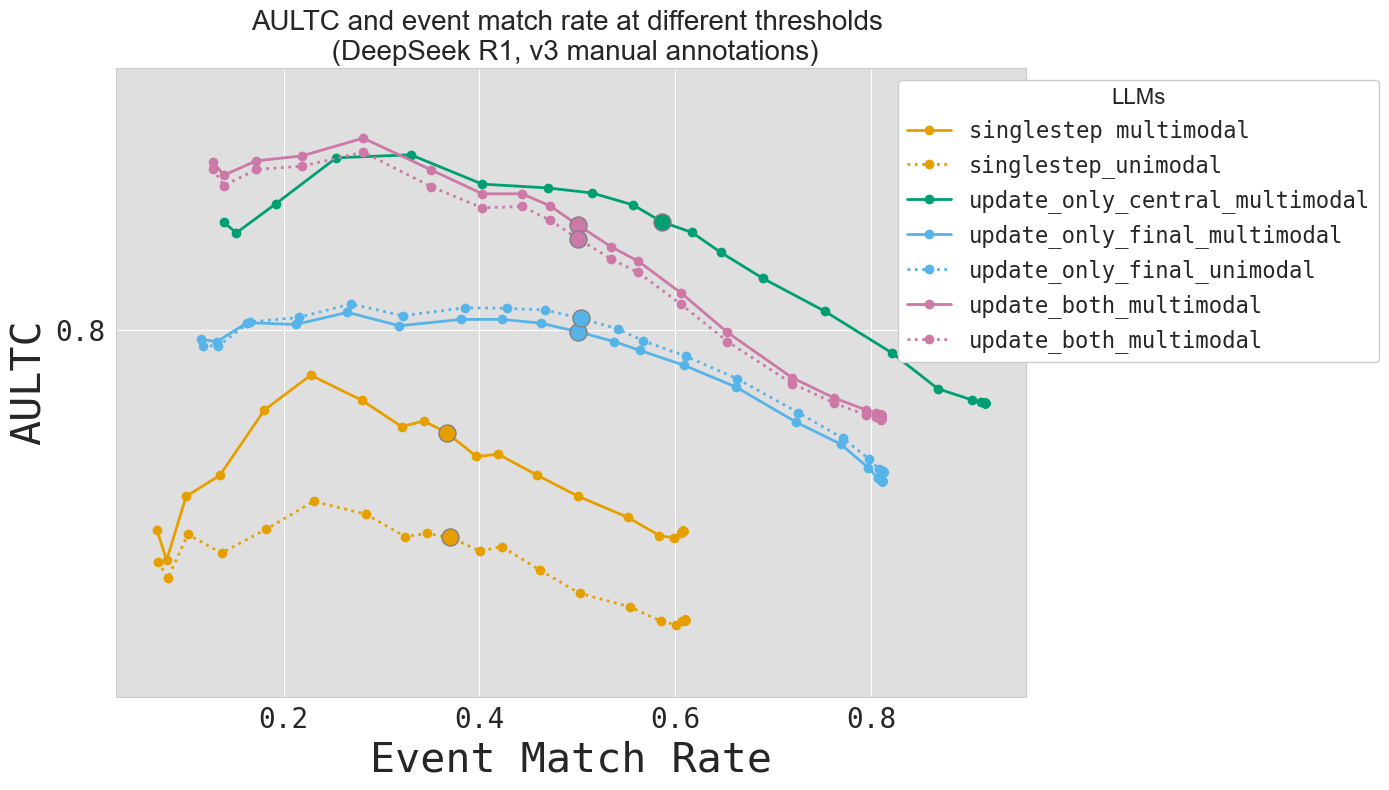

In [290]:
# Create AULTC vs Event Match Rate figure
plt.figure(figsize=(15, 8))

for pilot, data in results.items():
    thresholds = np.array(data['thresholds'])
    event_match_rate = np.array(data['event_match_rate'])
    aultc = np.array(data['aultc'])

    if pilot == 'DSR1':
        # Skip DSR1 for AULTC plot as per original code
        event_match_rate = event_match_rate.copy() - 0.096481
        aultc = aultc.copy() - 0.10006602895718808
        # break
    
    # Get the proper model name and color from the mapping
    model_name = model_name_mapping.get(pilot, pilot)
    color = color_mapping.get(pilot, '#000000')  # Default to black if no color found

    # Highlight threshold = 0.1
    highlight_idx = thresholds == 0.1
    highlight_x = event_match_rate[highlight_idx]
    highlight_y = aultc[highlight_idx]

    if '_um' in pilot:
        plt.plot(event_match_rate, aultc, label=model_name, marker='o', markersize=6, linestyle=':', linewidth=2, color=color)
    else:
        plt.plot(event_match_rate, aultc, label=model_name, marker='o', markersize=6, linestyle='-', linewidth=2, color=color)
        
    # Plot AULTC vs Event Match Rate
    #plt.plot(event_match_rate, aultc, label=model_name, marker='o', markersize=6, linestyle='-', linewidth=3, color=color)
    
    # Highlight with same color as the line, but with a black border
    plt.scatter(highlight_x, highlight_y, color=color, s=150, zorder=5, edgecolor='gray', linewidth=1)  # Highlight with border

# Set y-axis ticks to 0.7, 0.8, 0.9, 1.0
plt.yticks(np.arange(0.6, 1.1, 0.1), fontsize=20, family='monospace')

plt.xlabel('Event Match Rate', fontsize=30, family='monospace')
plt.ylabel('AULTC', fontsize=30, family='monospace')

# Customize grid and background
plt.grid('major', color='white')
plt.gca().set_facecolor('#DFDFDF')

plt.xticks(fontsize=20, family='monospace')
plt.yticks(fontsize=20, family='monospace')

# Modify the legend to have a solid background
plt.legend(title='LLMs', title_fontsize=16, loc='upper right', bbox_to_anchor=(1.4, 1), prop={'family': 'monospace', 'size': 16}, 
           frameon=True, facecolor='white', framealpha=1)

plt.title("AULTC and event match rate at different thresholds \n (DeepSeek R1, v3 manual annotations)", fontsize = 20)
# Tight layout for better spacing
plt.tight_layout()

# Limit y-axis to [0.7, 1.0]
plt.ylim(0.73, 0.85)

plt.savefig('/Users/kumars33/Desktop/TTA/Textual_tabular_alignment-main/LLM_TTS/ablations/ablation_aultc_dsr1_manualv3.pdf', bbox_inches='tight', dpi=300)

# Show plot
plt.show()
